# EDA Notebook — Stroke Prediction Dataset

## Milestones covered in this notebook
This notebook covers:
- **Milestone 1: Data Collection, Exploration, and Preprocessing**
- **Milestone 2: Data Analysis and Visualization**

## Dataset summary
- **Source**: `healthcare-dataset-stroke-data.csv`
- **Rows / columns**: 5,110 records and 12 columns.
- **Target**: `stroke` (1 = stroke, 0 = no stroke).
- **Unit of analysis**: each row represents **one patient**.
- **Note**: `id` is an identifier (not useful for modeling).



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from mpl_toolkits.mplot3d import Axes3D 
import plotly.express as px
import plotly.graph_objects as go


In [2]:
DATA_PATH = Path("..") / "dataset" / "healthcare-dataset-stroke-data.csv"
df = pd.read_csv(DATA_PATH)
df["bmi"] = pd.to_numeric(df["bmi"], errors="coerce")


In [3]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [5]:
df.isnull().sum().sort_values(ascending=False) / len(df) * 100


bmi                  3.933464
id                   0.000000
age                  0.000000
gender               0.000000
hypertension         0.000000
heart_disease        0.000000
work_type            0.000000
ever_married         0.000000
Residence_type       0.000000
avg_glucose_level    0.000000
smoking_status       0.000000
stroke               0.000000
dtype: float64

## Quick preview
We load the dataset and inspect the first rows to confirm column names, types, and the target variable.

**Expectation**: one row = one patient record, with `stroke` as the outcome label.

## Milestone 1 — Data Collection, Exploration, and Preprocessing

### Data Quality Checks
We check for obvious data issues before deeper analysis:
- **Duplicates** (overall rows and repeated `id`)
- **Unique values per column** (to spot identifiers vs features)
- **Category levels** (to catch rare values like `gender = Other`)

In [6]:
dup_rows = df.duplicated().sum()
dup_id = df["id"].duplicated().sum()
dup_rows, dup_id

(np.int64(0), np.int64(0))

In [7]:
df.nunique().sort_values()

hypertension            2
Residence_type          2
ever_married            2
heart_disease           2
stroke                  2
gender                  3
smoking_status          4
work_type               5
age                   104
bmi                   418
avg_glucose_level    3979
id                   5110
dtype: int64

In [8]:
df["gender"].value_counts(dropna=False)


gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

In [9]:
df["work_type"].value_counts(dropna=False)

work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

In [10]:
df["smoking_status"].value_counts(dropna=False)

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64

In [11]:
stroke_counts = df["stroke"].value_counts()
stroke_ratio = df["stroke"].value_counts(normalize=True)

stroke_counts, stroke_ratio

(stroke
 0    4861
 1     249
 Name: count, dtype: int64,
 stroke
 0    0.951272
 1    0.048728
 Name: proportion, dtype: float64)

## Target analysis
We inspect the target label `stroke` to understand **class balance**.

**Important**: This dataset is highly imbalanced (~4.9% stroke). Later, we will not rely on accuracy alone; we will emphasize **Recall, F1-score, ROC-AUC, and PR-AUC**.

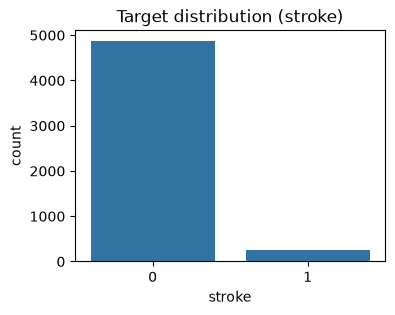

In [12]:
plt.figure(figsize=(4,3))
sns.countplot(data=df, x="stroke")
plt.title("Target distribution (stroke)")
plt.show()

In [13]:
stroke_pct = df["stroke"].value_counts(normalize=True) * 100
stroke_pct

stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64

**Insight**: Target distribution is highly imbalanced.
- A naive model predicting `stroke = 0` for everyone would look good on accuracy.
- We will prioritize Recall/F1 and PR-AUC in later modeling.

## distributions (numerical)
We plot distributions for the main numeric features:
- `age`
- `avg_glucose_level`
- `bmi`

This helps identify skewness/outliers and informs preprocessing (e.g., transformations or robust models).

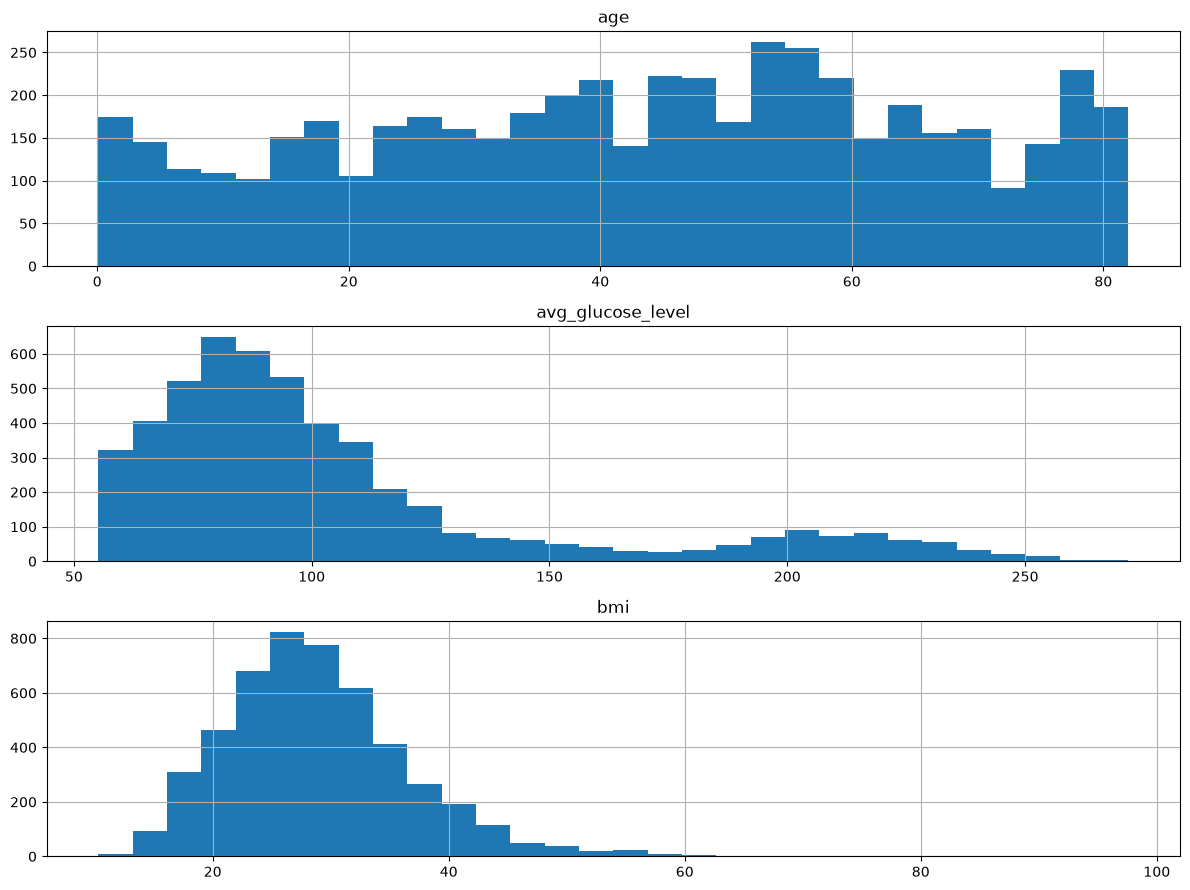

In [14]:
num_cols = ["age", "avg_glucose_level", "bmi"]
df[num_cols].hist(bins=30, figsize=(12,9),layout=(3, 1))
plt.tight_layout()
plt.show()

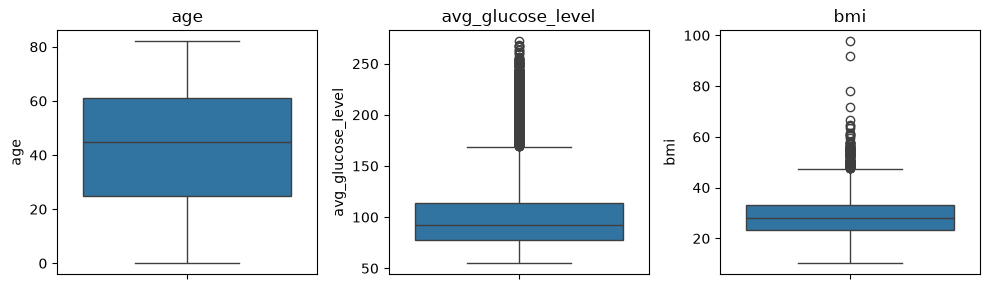

In [15]:
plt.figure(figsize=(10,3))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(data=df, y=col)
    plt.title(col)
plt.tight_layout()
plt.show()

**Insight**: Numeric distributions
- `avg_glucose_level` is right-skewed with high values (potential outliers).
- `bmi` contains missing values; we handle this later with imputation.

## Outlier discussion (numeric)
From the histograms/boxplots, `avg_glucose_level` and `bmi` contain high-end outliers.

**Decision**: we will not drop outliers in Milestone 1 (to avoid removing rare stroke cases). Instead we will:
- keep values as-is for now
- consider robust models (tree-based) and/or transformations (e.g., log for glucose) in Milestone 3
- optionally apply winsorization/capping later if it improves validation performance


In [16]:
def iqr_outlier_summary(s):
    s = s.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    out = ((s < lo) | (s > hi)).sum()
    return pd.Series({"q1": q1, "q3": q3, "iqr": iqr, "lo": lo, "hi": hi, "outliers_count": int(out), "outliers_pct": out/len(s)*100})

outlier_report = pd.DataFrame({c: iqr_outlier_summary(df[c]) for c in ["avg_glucose_level", "bmi"]}).T
outlier_report

,q1,q3,iqr,lo,hi,outliers_count,outliers_pct
avg_glucose_level,77.245,114.09,36.845,21.9775,169.3575,627.0,12.270059
bmi,23.500,33.10,9.600,9.1000,47.5000,110.0,2.240782


**Insight**: IQR outliers are expected in clinical measures.
- We document how many values fall outside the 1.5×IQR range.
- We avoid deleting them in Milestone 1; handling will be validated in Milestone 3.

**Insight**: Categorical distributions show data coverage.
- Some categories are rare (e.g., `Never_worked`, `gender = Other`), so we should be cautious interpreting their stroke rates.
- `smoking_status = Unknown` is common, so it may carry signal on its own.

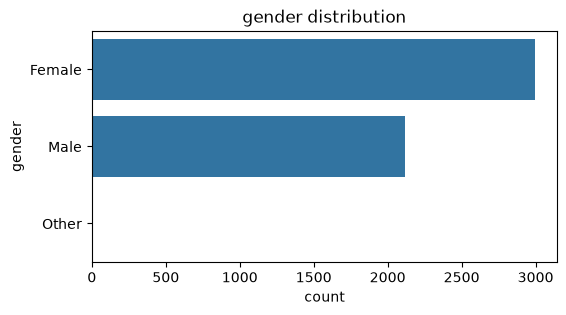

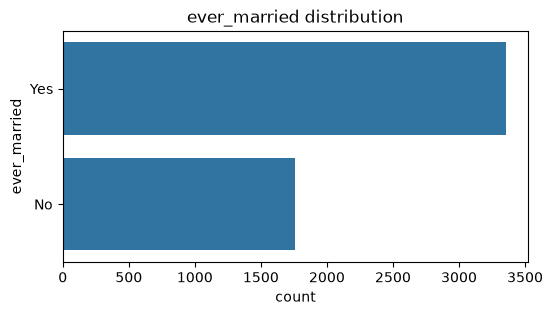

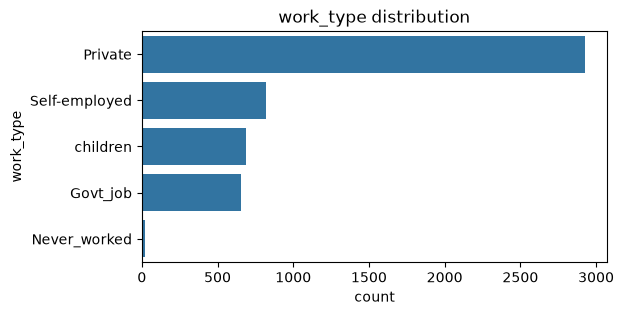

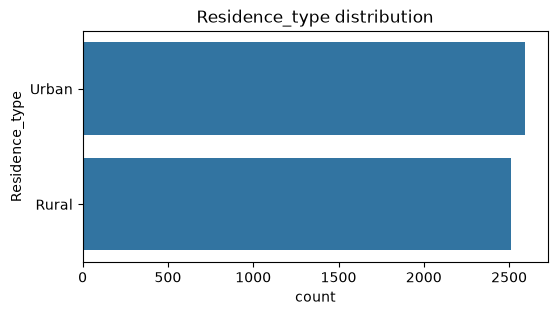

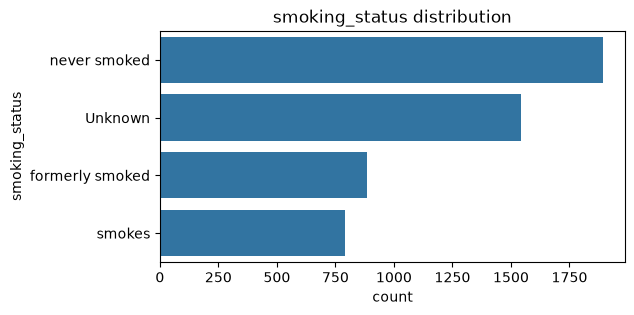

In [17]:
cat_cols = ["gender","ever_married","work_type","Residence_type","smoking_status"]

for col in cat_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(data=df, y=col, order=df[col].value_counts().index)
    plt.title(f"{col} distribution")
    plt.show()

In [18]:
for col in cat_cols:
    display(df[col].value_counts())

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

ever_married
Yes    3353
No     1757
Name: count, dtype: int64

work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64

**Insight**: Categorical distributions show data coverage.
- Some categories are rare (e.g., `Never_worked`, `gender = Other`), so we should be cautious interpreting their stroke rates.
- `smoking_status = Unknown` is common, so it may carry signal on its own.

# Milestone 2 — Data Analysis and Visualization

## Bivariate analysis vs target
In this section we compare each feature against the target `stroke` to identify the most informative predictors.

Goal: understand **which variables differ between stroke vs non-stroke** before modeling.

## Numeric vs stroke
We compare numeric feature distributions by `stroke` using plots (KDE/boxplots).

What to look for:
- **Age shift** (stroke cases tend to be older)
- **Glucose** right-skew and potential outliers
- **BMI** distribution differences (after handling missing values later)

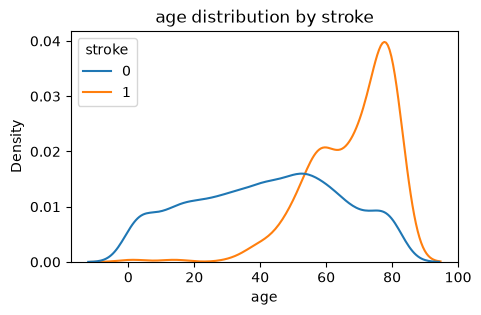

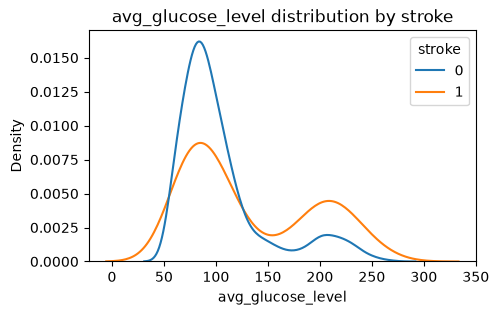

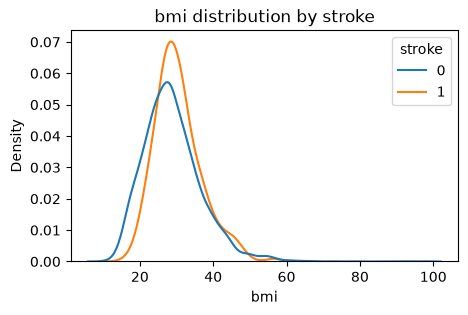

In [19]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.kdeplot(data=df, x=col, hue="stroke", common_norm=False)
    plt.title(f"{col} distribution by stroke")
    plt.show()

C:\Users\georg\AppData\Local\Temp\ipykernel_23324\2732458096.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_stroke_rate = df.groupby("age_group")["stroke"].mean() * 100


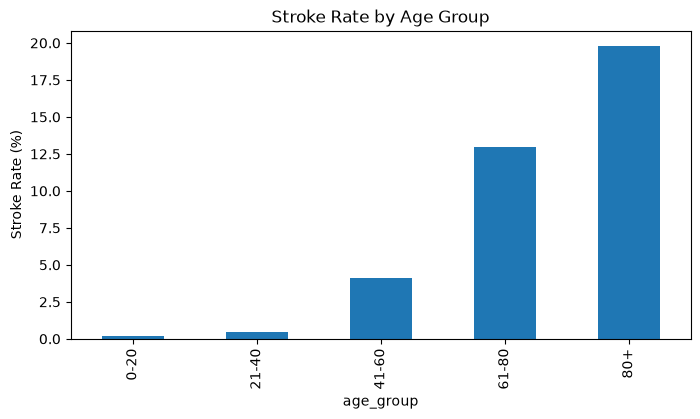

In [20]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 20, 40, 60, 80, 100],
    labels=["0-20", "21-40", "41-60", "61-80", "80+"]
)

age_stroke_rate = df.groupby("age_group")["stroke"].mean() * 100

age_stroke_rate.plot(kind="bar", figsize=(8,4), title="Stroke Rate by Age Group")
plt.ylabel("Stroke Rate (%)")
plt.show()

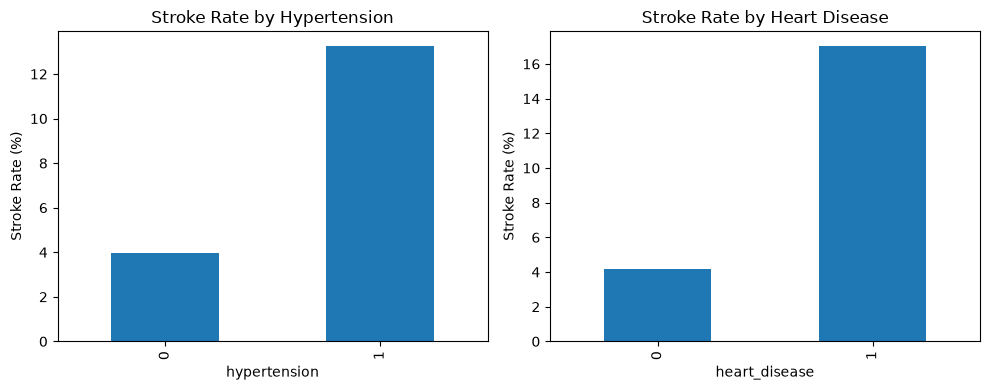

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

(df.groupby("hypertension")["stroke"].mean() * 100).plot(
    kind="bar", ax=axes[0], title="Stroke Rate by Hypertension"
)
axes[0].set_ylabel("Stroke Rate (%)")

(df.groupby("heart_disease")["stroke"].mean() * 100).plot(
    kind="bar", ax=axes[1], title="Stroke Rate by Heart Disease"
)
axes[1].set_ylabel("Stroke Rate (%)")

plt.tight_layout()
plt.show()

C:\Users\georg\AppData\Local\Temp\ipykernel_23324\1553189610.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  glucose_rate = df.groupby("glucose_group")["stroke"].mean() * 100


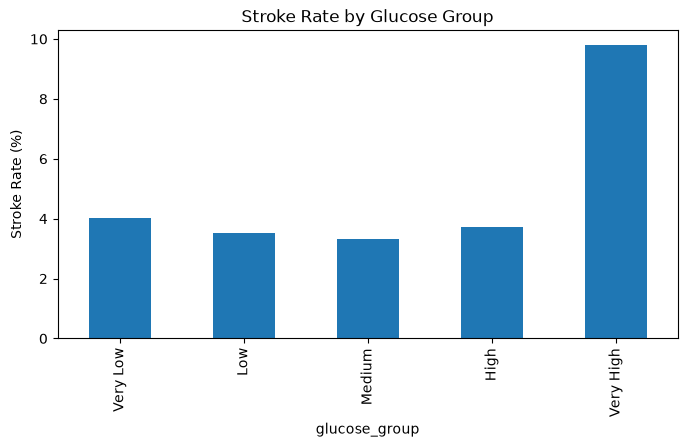

In [22]:
df["glucose_group"] = pd.qcut(
    df["avg_glucose_level"],
    q=5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

glucose_rate = df.groupby("glucose_group")["stroke"].mean() * 100

glucose_rate.plot(kind="bar", figsize=(8,4), title="Stroke Rate by Glucose Group")
plt.ylabel("Stroke Rate (%)")
plt.show()

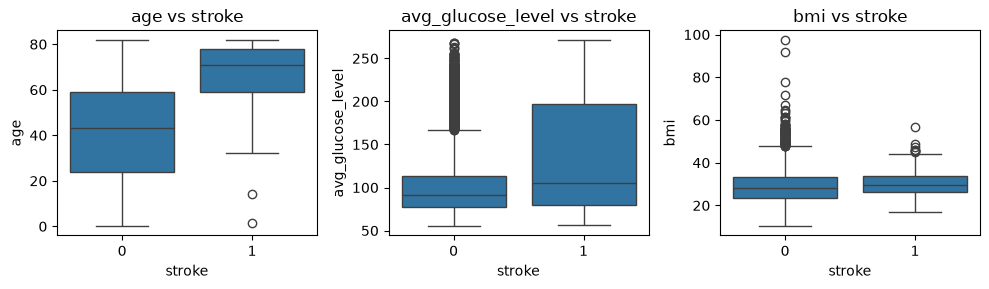

In [23]:
plt.figure(figsize=(10,3))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(data=df, x="stroke", y=col)
    plt.title(f"{col} vs stroke")
plt.tight_layout()
plt.show()

**Insight**: Numeric features show separation between classes.
- If stroke vs non-stroke distributions differ clearly (especially in `age`), that feature is likely predictive.
- For imbalanced data, the overlap still matters: we’ll later tune thresholds to reduce false negatives.

## Categorical vs stroke
For categorical variables, we compute **stroke rate per category**:

\(\text{stroke rate} = \frac{\text{# stroke=1}}{\text{total in category}}\)

This is more useful than raw counts because the dataset is imbalanced.

In [24]:
def stroke_rate_by(col):
    out = (
        df.groupby(col)["stroke"]
          .agg(rate="mean", count="size")
          .sort_values("rate", ascending=False)
    )
    return out

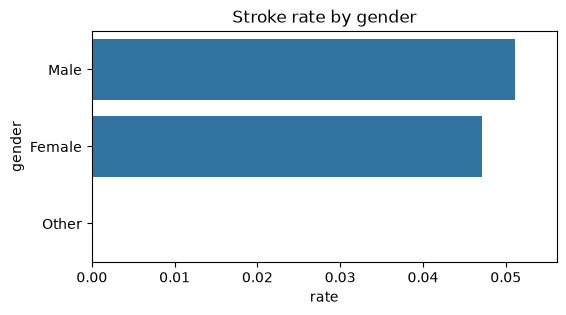

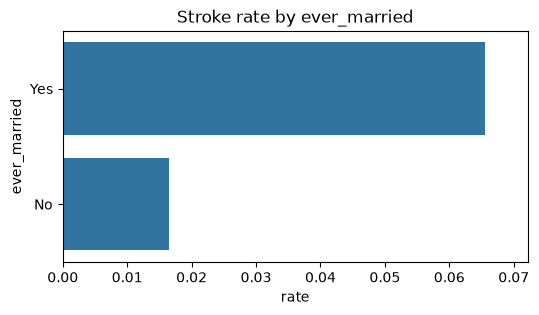

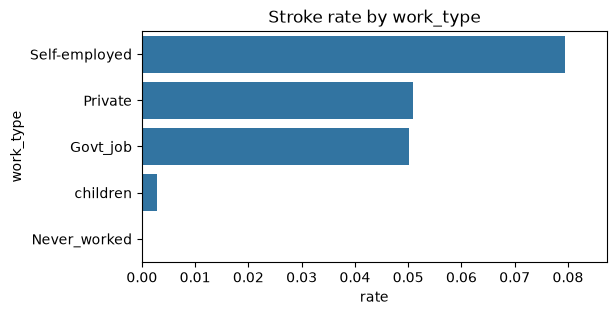

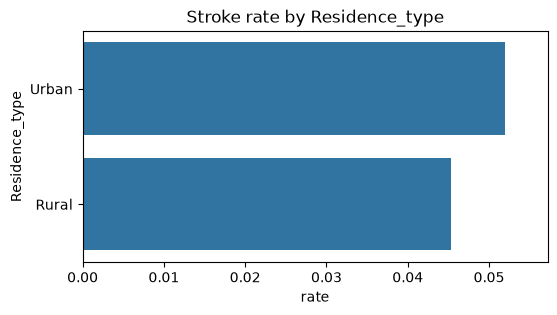

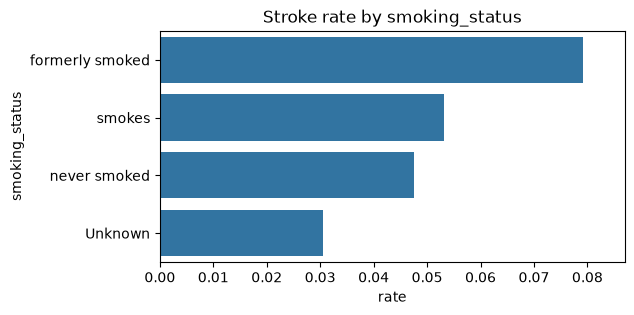

In [25]:
for col in cat_cols:
    tmp = stroke_rate_by(col).reset_index()

    plt.figure(figsize=(6,3))
    sns.barplot(data=tmp, x="rate", y=col)
    plt.title(f"Stroke rate by {col}")
    plt.xlim(0, tmp["rate"].max() * 1.1)
    plt.show()

In [26]:
for col in cat_cols:
    display(stroke_rate_by(col))

,rate,count
gender,,
Male,0.051064,2115
Female,0.047094,2994
Other,0.000000,1


,rate,count
ever_married,,
Yes,0.065613,3353
No,0.016505,1757


,rate,count
work_type,,
Self-employed,0.079365,819
Private,0.050940,2925
Govt_job,0.050228,657
children,0.002911,687
Never_worked,0.000000,22


,rate,count
Residence_type,,
Urban,0.052003,2596
Rural,0.045346,2514


,rate,count
smoking_status,,
formerly smoked,0.079096,885
smokes,0.053232,789
never smoked,0.047569,1892
Unknown,0.030440,1544


**Insight**: Stroke rate by category highlights which groups have higher observed risk.
- We keep both **rate** and **count** to avoid over-interpreting very small groups.
- These patterns help prioritize features for Milestone 3 modeling.

## Correlation Matrix
We compute correlations among numeric variables to spot strong linear relationships.

Note: correlation does not imply causation, and it may miss non-linear effects, but it helps with feature understanding.

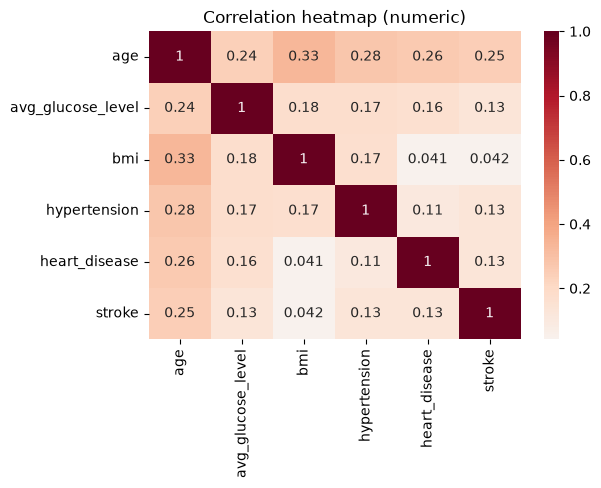

In [27]:
num_df = df[["age","avg_glucose_level","bmi","hypertension","heart_disease","stroke"]]
corr = num_df.corr(numeric_only=True)

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0)
plt.title("Correlation heatmap (numeric)")
plt.show()

**Insight**: Correlation is a quick sanity check.
- We mainly expect positive association between `stroke` and risk-related features (e.g., `age`, `hypertension`, `heart_disease`).
- Correlations are limited to linear relationships, so we still rely on the bivariate plots + models later.

## Missing values analysis
Only `bmi` has missing values (**201 rows ~3.9%**).

### Why this matters
A quick check shows stroke rate is **much higher** when BMI is missing, so missingness is not random.

### Leakage-safe decision
This EDA notebook documents the missingness pattern only. It does **not** fill missing BMI values, because filling before the split would let information from validation/test rows influence preprocessing.

The Modeling notebook will:
- split the data first,
- add `bmi_missing` to each split,
- fit missing-value handling only inside the training/CV pipeline.

### Note on `gender = Other`
The dataset contains **only 1** row with `gender = Other`.

For modeling later, we can safely **merge it into `Unknown`** (or another strategy) to avoid unstable one-hot columns from extremely rare categories.

In [28]:
print(df["bmi"].isna().sum())
print(df["bmi"].isna().mean())

201
0.03933463796477495


In [29]:
#Check if missingness is biased :
df.assign(bmi_missing=df["bmi"].isna()).groupby("bmi_missing")["stroke"].mean()

bmi_missing
False    0.042575
True     0.199005
Name: stroke, dtype: float64

In [30]:
missing_value_plan = pd.DataFrame(
    [
        {
            "feature": "bmi",
            "missing_rows": int(df["bmi"].isna().sum()),
            "missing_percent": df["bmi"].isna().mean() * 100,
            "eda_action": "Analyze missingness only; do not fill in EDA",
            "modeling_action": "Add bmi_missing and fit missing-value handling after train/validation/test split",
        }
    ]
)

display(missing_value_plan.round({"missing_percent": 3}))

,feature,missing_rows,missing_percent,eda_action,modeling_action
0,bmi,201,3.933,Analyze missingness only; do not fill in EDA,Add bmi_missing and fit missing-value handling...


## Data cleaning decisions (Milestone 1)
- **Drop `id` for modeling**: identifier only; this will be done in the Modeling notebook.
- **Handle rare categories**: `gender = Other` appears once ? merge or handle during modeling to avoid unstable one-hot columns.
- **Missing values**: only `bmi` is missing (~3.9%).
  - Do **not** impute BMI in EDA.
  - Defer `bmi_missing` creation and missing-value handling to the Modeling notebook after the split.
- **Duplicates**: none found in rows or `id`.
- **Outliers**: documented (IQR check); not removed in Milestone 1.

## Preprocessing plan for modeling (Milestone 3)
When building the predictive model, we will:
- **Split data first** using a **stratified train/validation/test split**.
- Add `bmi_missing` separately to each split after splitting.
- **Preprocess with a pipeline** to avoid leakage:
  - numeric: missing-value handling fitted on training folds only, then optional scaling
  - categorical: missing-value handling + one-hot encoding fitted on training folds only
- **Model tuning**: use `GridSearchCV` on the training split for each candidate model.
- **Evaluation**: emphasize **Recall**, **F1**, **ROC-AUC**, and **PR-AUC**.
- **Threshold tuning**: adjust the decision threshold on validation data only.

**Insight**: BMI missingness is meaningful.
- Even though only ~3.9% of BMI values are missing, the stroke rate is much higher in rows with missing BMI.
- This supports adding `bmi_missing` in the Modeling notebook.
- Missing-value handling should be fitted only after splitting, inside the training/CV pipeline, to prevent data leakage.

## Milestone 1 complete ready for modeling
At this point, we have:
- validated the dataset structure and target,
- documented key EDA insights (including class imbalance),
- documented BMI missingness without imputing it in EDA,
- identified preprocessing decisions to apply leakage-safely in the Modeling notebook.

**Next step (Modeling notebook / Milestone 3):** split first, add missing indicators per split, fit imputers inside pipelines, tune models with GridSearchCV, and evaluate on a held-out test set.

## Key EDA Findings

1. The dataset is highly imbalanced: only about 4.9% of patients had a stroke.
2. Age is the strongest visible risk-related feature. Stroke rate increases clearly in older age groups.
3. Hypertension and heart disease are associated with higher stroke rates.
4. Average glucose level is right-skewed and higher glucose groups show higher stroke rates.
5. BMI has 201 missing values, around 3.9% of the dataset.
6. BMI missingness appears informative because rows with missing BMI have a higher stroke rate.
7. Some categories are rare, such as `gender = Other` and `Never_worked`, so their stroke rates should not be over-interpreted.
8. Because of class imbalance, future modeling should use Recall, F1-score, ROC-AUC, and PR-AUC instead of accuracy alone.
